In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

### Helper Functions

#### JSON TO CSV

In [2]:
def json_to_csv(
    json_file: str,
    csv_file: str | None = None,
) -> pd.DataFrame:
    
    ''' 
    Converts JSON to CSV and add one column called the weighted sentiment by multiplying the 3 factors that exists
    '''
    
    articles = pd.read_json(json_file)

    rows = [
        stock
        for article_stocks in articles["stocks"]
        for stock in article_stocks
    ]

    sentiment_df = pd.DataFrame(rows)

    if not sentiment_df.empty and "date" in sentiment_df.columns:
        sentiment_df["date"] = pd.to_datetime(
            sentiment_df["date"]
        )

    if csv_file is not None:
        sentiment_df.to_csv(
            csv_file,
            index=False,
            encoding="utf-8-sig",
        )

    sentiment_df['weighted_sentiment'] = sentiment_df['sentiment_score'] * sentiment_df['relevance'] * sentiment_df['confidence']

    return sentiment_df

#### Filter by Universe

In [3]:
def filter_by_universe(
    sentiment_df: pd.DataFrame,
    universe_df: pd.DataFrame,
    cutoff_date: str = "2026-06-15",
) -> pd.DataFrame:

    sentiment = sentiment_df.copy()
    universe = universe_df.copy()

    if "date" not in universe.columns:
        universe = universe.reset_index()

    universe = universe.rename(
        columns={"stock": "ticker"}
    )

    sentiment["ticker"] = (
        sentiment["ticker"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    universe["ticker"] = (
        universe["ticker"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    sentiment["date"] = pd.to_datetime(
        sentiment["date"],
        errors="coerce",
    ).dt.normalize()

    universe["date"] = pd.to_datetime(
        universe["date"],
        errors="coerce",
    ).dt.normalize()

    cutoff = pd.Timestamp(cutoff_date)

    eligible_universe = (
        universe.loc[
            universe["uni"].eq(1),
            ["date", "ticker"],
        ]
        .dropna()
        .drop_duplicates()
    )

    eligible_pairs = pd.MultiIndex.from_frame(
        eligible_universe[["date", "ticker"]]
    )

    sentiment_pairs = pd.MultiIndex.from_frame(
        sentiment[["date", "ticker"]]
    )

    keep_mask = (
        sentiment["date"].gt(cutoff)
        | sentiment_pairs.isin(eligible_pairs)
    )

    filtered = sentiment.loc[keep_mask].copy()

    return filtered

#### EWMA

In [4]:
''' 
Look for EWMA for a given number of days of half-life
'''

def make_ewma(data: pd.DataFrame, filter: str = 'avg_weighted_sentiment', halflife_value: int = 5) -> pd.DataFrame:

    data = data.sort_values(
        ["ticker", "date"]
    ).copy()       

    data[f"ewma_{filter}"] = (
    data
    .groupby("ticker")[filter]
    .transform(
        lambda x: x.ewm(
            halflife=halflife_value,
            adjust=False,
            min_periods=1,
        ).mean()
        )
    ) 

    return data


#### t-stat calculator

In [5]:
def stat_summary(table_df: pd.DataFrame) -> pd.DataFrame:

    count = pd.to_numeric(table_df.loc['count'], errors='coerce')
    mean  = pd.to_numeric(table_df.loc['mean'],  errors='coerce')
    std   = pd.to_numeric(table_df.loc['std'],   errors='coerce')

    t_stat = mean / (std / np.sqrt(count))

    table_df.loc['t-stat'] = t_stat

    return table_df

In [6]:
# For Newey-West Calculation

import statsmodels.api as sm


def newey_west_summary(
    data_df: pd.DataFrame,
    maxlags: int = 4,
) -> pd.DataFrame:

    data_df = (
        data_df
        .sort_index()
        .apply(pd.to_numeric, errors="coerce")
        .dropna(axis=1, how="all")
    )

    summary = data_df.describe()

    nw_standard_errors = {}
    nw_t_stats = {}
    nw_p_values = {}
    nw_ci_lower = {}
    nw_ci_upper = {}

    for column in data_df.columns:

        series = data_df[column].dropna()

        if len(series) < 2 or series.std() == 0:
            nw_standard_errors[column] = np.nan
            nw_t_stats[column] = np.nan
            nw_p_values[column] = np.nan
            nw_ci_lower[column] = np.nan
            nw_ci_upper[column] = np.nan
            continue

        # Intercept-only regression:
        # value_t = mean + error_t
        X = np.ones((len(series), 1))

        result = sm.OLS(
            series.to_numpy(),
            X,
        ).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": maxlags},
            use_t=True,
        )

        confidence_interval = result.conf_int()[0]

        nw_standard_errors[column] = result.bse[0]
        nw_t_stats[column] = result.tvalues[0]
        nw_p_values[column] = result.pvalues[0]
        nw_ci_lower[column] = confidence_interval[0]
        nw_ci_upper[column] = confidence_interval[1]

    summary.loc["NW standard error"] = pd.Series(
        nw_standard_errors
    )

    summary.loc["NW t-stat"] = pd.Series(
        nw_t_stats
    )

    summary.loc["NW p-value"] = pd.Series(
        nw_p_values
    )

    return summary

### Set Data

In [7]:
indo_stock = pd.read_csv('price_last_capchg.csv')
indo_stock = indo_stock.set_index('date')
indo_stock_returns = indo_stock.pct_change()
indo_stock_returns.index = pd.to_datetime(indo_stock_returns.index)

In [8]:
invuni = pd.read_parquet('invuni_v2.parquet')

In [9]:
data = json_to_csv('all_articles.json')[['date','ticker','relevance','sentiment_score','confidence','weighted_sentiment']]
data = data.drop(data[data['sentiment_score']==0].index)

In [77]:
data2 = pd.read_csv('data2.csv')[['date','ticker','relevance','sentiment_score','confidence','weighted_sentiment']]

In [80]:
data = data2.copy()

### Data Preprocessing

In [205]:
'''
Filter whats in the universe, group by each respective ticker and dates.
Set multi-index with date & ticker
'''

data = filter_by_universe(data,invuni)

sentiment_df = data.groupby(['ticker', 'date']).agg(
        mention_count=('ticker', 'count'),
        avg_sentiment=('sentiment_score', 'mean'),
        avg_weighted_sentiment=('weighted_sentiment', 'mean')
    ).reset_index()


In [206]:
''' 
Make daily data for each stock to consolidate for the EWMA calculation
'''

sentiment = sentiment_df.copy()

sentiment["date"] = pd.to_datetime(
    sentiment["date"]
).dt.normalize()

sentiment["ticker"] = (
    sentiment["ticker"]
    .astype(str)
    .str.strip()
    .str.upper()
)


sentiment = (
    sentiment.groupby(
        ["date", "ticker"],
        as_index=False,
    )
    .agg(
        mention_count=("mention_count", "sum"),
        avg_sentiment=("avg_sentiment", "mean"),
        avg_weighted_sentiment=(
            "avg_weighted_sentiment",
            "mean",
        ),
    )
)


trading_dates = pd.DatetimeIndex(
    indo_stock_returns.index
).normalize()

trading_dates = trading_dates[
    (trading_dates >= sentiment["date"].min())
    & (trading_dates <= sentiment["date"].max())
]

tickers = sentiment["ticker"].unique()


full_index = pd.MultiIndex.from_product(
    [trading_dates, tickers],
    names=["date", "ticker"],
)

sentiment_filled = (
    sentiment
    .set_index(["date", "ticker"])
    .reindex(full_index)
    .fillna(0))



In [207]:
df_sentiment = make_ewma(sentiment_filled)
df_sentiment = make_ewma(df_sentiment, 'avg_sentiment')

In [208]:
df_sentiment = df_sentiment.reset_index()
df_sentiment = filter_by_universe(df_sentiment, invuni)
df_sentiment = df_sentiment[df_sentiment['date']<'2026-06-16']

In [209]:

''' 
Assigns 'target' as the return from T+1 to T+2.
'''

df_sentiment["date"] = pd.to_datetime(
    df_sentiment["date"]
).dt.normalize()

indo_stock_returns.index = pd.to_datetime(
    indo_stock_returns.index
).normalize()

# Align each stock's T+2 return with signal date T
future_returns = (
    indo_stock_returns
    .shift(-1)
    .rename_axis("date")
    .reset_index()
    .melt(
        id_vars="date",
        var_name="ticker",
        value_name="day_return",
    )
)

# Ensure ticker formatting matches
df_sentiment["ticker"] = (
    df_sentiment["ticker"]
    .astype(str)
    .str.strip()
    .str.upper()
)

future_returns["ticker"] = (
    future_returns["ticker"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df_sentiment = df_sentiment.merge(
    future_returns,
    on=["date", "ticker"],
    how="left",
    validate="many_to_one",
)

C:\Users\Kentz\AppData\Local\Temp\ipykernel_27524\424558200.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()


In [210]:
''' 
Assigns another target for the cum-return for 5-trading days
'''

future_5d_returns = (
    (1 + indo_stock_returns.shift(-1))
    *(1 + indo_stock_returns.shift(-2))
    * (1 + indo_stock_returns.shift(-3))
    * (1 + indo_stock_returns.shift(-4))
    * (1 + indo_stock_returns.shift(-5))
    - 1
)

future_5d_long = (
    future_5d_returns
    .rename_axis("date")
    .reset_index()
    .melt(
        id_vars="date",
        var_name="ticker",
        value_name="week_return",
    )
)

df_sentiment = df_sentiment.merge(
    future_5d_long,
    on=["date", "ticker"],
    how="left",
    validate="many_to_one",
)

C:\Users\Kentz\AppData\Local\Temp\ipykernel_27524\3065121497.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()


In [211]:
df_sentiment

,date,ticker,mention_count,avg_sentiment,avg_weighted_sentiment,ewma_avg_weighted_sentiment,ewma_avg_sentiment,day_return,week_return
0,2025-07-10,AADI,0.0,0.0,0.000,0.000000,0.000000,0.003584,-0.021505
1,2025-07-11,AADI,0.0,0.0,0.000,0.000000,0.000000,-0.010714,-0.025000
2,2025-07-14,AADI,1.0,0.5,0.375,0.048544,0.064725,0.014440,-0.025271
3,2025-07-15,AADI,0.0,0.0,0.000,0.042260,0.056346,-0.014235,-0.007117
4,2025-07-16,AADI,1.0,0.0,0.000,0.036789,0.049052,-0.014440,0.036101
...,...,...,...,...,...,...,...,...,...
60125,2026-06-09,ZINC,0.0,0.0,0.000,0.000000,0.000000,0.000000,0.000000
60126,2026-06-10,ZINC,0.0,0.0,0.000,0.000000,0.000000,0.000000,0.000000
60127,2026-06-11,ZINC,0.0,0.0,0.000,0.000000,0.000000,0.000000,0.000000
60128,2026-06-12,ZINC,0.0,0.0,0.000,0.000000,0.000000,0.000000,0.000000


### Analysis

#### Count Daily News/mention_count

In [212]:
# Look for the number of news each day and finding its distribution
df_sentiment.groupby('date').sum()['mention_count'].describe(include='all')

count    222.000000
mean     242.432432
std       87.812493
min        4.000000
25%      193.000000
50%      238.500000
75%      286.000000
max      546.000000
Name: mention_count, dtype: float64

In [213]:
# Unique number of reported stocks
df_sentiment[df_sentiment['mention_count']>0].groupby('date').count()[['mention_count']]

,mention_count
date,
2025-07-10,5
2025-07-11,4
2025-07-14,60
2025-07-15,55
2025-07-16,81
...,...
2026-06-09,78
2026-06-10,74
2026-06-11,80


In [214]:
df_sentiment[df_sentiment['mention_count']>0].groupby('date').count()[['mention_count']].describe()

,mention_count
count,222.000000
mean,72.882883
std,14.904971
min,4.000000
25%,66.000000
50%,74.000000
75%,81.000000
max,108.000000


#### Information Coefficient

In [215]:
daily_corr_week_return = pd.concat(
    {
        "avg_sentiment": (
            df_sentiment
            .dropna(subset=["avg_sentiment", "week_return"])
            .groupby("date")
            .apply(
                lambda group: group["avg_sentiment"].corr(
                    group["week_return"]
                )
            )
        ),

        "avg_weighted_sentiment": (
            df_sentiment
            .dropna(subset=["avg_weighted_sentiment", "week_return"])
            .groupby("date")
            .apply(
                lambda group: group["avg_weighted_sentiment"].corr(
                    group["week_return"]
                )
            )
        ),

        "ewma_avg_weighted_sentiment": (
            df_sentiment
            .dropna(
                subset=[
                    "ewma_avg_weighted_sentiment",
                    "week_return",
                ]
            )
            .groupby("date")
            .apply(
                lambda group: group[
                    "ewma_avg_weighted_sentiment"
                ].corr(group["week_return"])
            )
        ),

        "ewma_avg_sentiment": (
            df_sentiment
            .dropna(subset=["ewma_avg_sentiment", "week_return"])
            .groupby("date")
            .apply(
                lambda group: group["ewma_avg_sentiment"].corr(
                    group["week_return"]
                )
            )
        ),
    },
    axis=1,
)

In [216]:
daily_corr_day_return = pd.concat(
    {
        "avg_sentiment": (
            df_sentiment
            .dropna(subset=["avg_sentiment", "day_return"])
            .groupby("date")
            .apply(
                lambda group: group["avg_sentiment"].corr(
                    group["day_return"]
                )
            )
        ),

        "avg_weighted_sentiment": (
            df_sentiment
            .dropna(subset=["avg_weighted_sentiment", "day_return"])
            .groupby("date")
            .apply(
                lambda group: group["avg_weighted_sentiment"].corr(
                    group["day_return"]
                )
            )
        ),

        "ewma_avg_weighted_sentiment": (
            df_sentiment
            .dropna(
                subset=[
                    "ewma_avg_weighted_sentiment",
                    "day_return",
                ]
            )
            .groupby("date")
            .apply(
                lambda group: group[
                    "ewma_avg_weighted_sentiment"
                ].corr(group["day_return"])
            )
        ),

        "ewma_avg_sentiment": (
            df_sentiment
            .dropna(subset=["ewma_avg_sentiment", "day_return"])
            .groupby("date")
            .apply(
                lambda group: group["ewma_avg_sentiment"].corr(
                    group["day_return"]
                )
            )
        ),
    },
    axis=1,
)

In [217]:
df_sentiment

,date,ticker,mention_count,avg_sentiment,avg_weighted_sentiment,ewma_avg_weighted_sentiment,ewma_avg_sentiment,day_return,week_return
0,2025-07-10,AADI,0.0,0.0,0.000,0.000000,0.000000,0.003584,-0.021505
1,2025-07-11,AADI,0.0,0.0,0.000,0.000000,0.000000,-0.010714,-0.025000
2,2025-07-14,AADI,1.0,0.5,0.375,0.048544,0.064725,0.014440,-0.025271
3,2025-07-15,AADI,0.0,0.0,0.000,0.042260,0.056346,-0.014235,-0.007117
4,2025-07-16,AADI,1.0,0.0,0.000,0.036789,0.049052,-0.014440,0.036101
...,...,...,...,...,...,...,...,...,...
60125,2026-06-09,ZINC,0.0,0.0,0.000,0.000000,0.000000,0.000000,0.000000
60126,2026-06-10,ZINC,0.0,0.0,0.000,0.000000,0.000000,0.000000,0.000000
60127,2026-06-11,ZINC,0.0,0.0,0.000,0.000000,0.000000,0.000000,0.000000
60128,2026-06-12,ZINC,0.0,0.0,0.000,0.000000,0.000000,0.000000,0.000000


In [218]:
stat_summary(daily_corr_day_return.describe(include='all'))

,avg_sentiment,avg_weighted_sentiment,ewma_avg_weighted_sentiment,ewma_avg_sentiment
count,222.000000,222.000000,222.000000,222.000000
mean,-0.006774,-0.005955,-0.008832,-0.009331
std,0.079279,0.079899,0.083526,0.084143
min,-0.203740,-0.204470,-0.269070,-0.273644
25%,-0.059957,-0.056249,-0.065246,-0.069307
50%,-0.010401,-0.011666,-0.008132,-0.012812
75%,0.047903,0.050984,0.043338,0.046459
max,0.220716,0.237758,0.258858,0.263572
t-stat,-1.273092,-1.110545,-1.575478,-1.652283


In [219]:
stat_summary(daily_corr_week_return.describe(include='all'))

,avg_sentiment,avg_weighted_sentiment,ewma_avg_weighted_sentiment,ewma_avg_sentiment
count,222.000000,222.000000,222.000000,222.000000
mean,-0.004956,-0.003540,-0.020849,-0.021268
std,0.079645,0.079903,0.084095,0.084123
min,-0.245225,-0.239418,-0.234786,-0.243862
25%,-0.062534,-0.060314,-0.079976,-0.080509
50%,-0.008428,-0.008476,-0.021476,-0.022357
75%,0.049385,0.046284,0.042941,0.043562
max,0.206716,0.211134,0.218284,0.220170
t-stat,-0.927168,-0.660195,-3.693974,-3.766902


In [220]:
newey_west_summary(daily_corr_week_return.describe(include='all'))

,avg_sentiment,avg_weighted_sentiment,ewma_avg_weighted_sentiment,ewma_avg_sentiment
count,8.000000,8.000000,8.000000,8.000000
mean,27.751825,27.753196,27.748529,27.747483
std,78.488220,78.487665,78.489555,78.489983
min,-0.245225,-0.239418,-0.234786,-0.243862
25%,-0.021955,-0.021436,-0.036101,-0.036895
50%,0.022214,0.021372,0.011046,0.011147
75%,0.111413,0.112711,0.117642,0.118135
max,222.000000,222.000000,222.000000,222.000000
NW standard error,15.211595,15.211287,15.211348,15.211782
NW t-stat,1.824386,1.824513,1.824199,1.824078


#### Bins / Spread

we want to rank stocks and divide them into 5 Bins comparing them in terms of 'ewma_avg_sentiment'. For each date/bins, we calculate the average target which is the day_return or week_return

Here, Q1 is the worst sentiments whilst Q5 lists the best sentiments

In [221]:
quintile_df = df_sentiment.copy()

quintile_df["date"] = pd.to_datetime(
    quintile_df["date"]
)

quintile_df = quintile_df.dropna(
    subset=[
        "ewma_avg_sentiment",
        "day_return",
    ]
)

In [222]:
quintile_df["sentiment_percentile"] = (
    quintile_df
    .groupby("date")["ewma_avg_sentiment"]
    .rank(
        method="average",
        pct=True,
    )
)

In [223]:
quintile_df["sentiment_quintile"] = pd.cut(
    quintile_df["sentiment_percentile"],
    bins=[
        0.0,
        0.2,
        0.4,
        0.6,
        0.8,
        1.0,
    ],
    labels=[
        "Q1",
        "Q2",
        "Q3",
        "Q4",
        "Q5",
    ],
    include_lowest=True,
)

In [224]:
quintile_df_2 = quintile_df[['date','ewma_avg_sentiment','day_return','week_return','sentiment_quintile']]
quintile_1 = quintile_df_2.groupby(['date','sentiment_quintile']).mean()
quintile_1 = quintile_1.reset_index(level='sentiment_quintile',drop=False)

In [225]:
quintile_1.groupby('sentiment_quintile').sum()

,ewma_avg_sentiment,day_return,week_return
sentiment_quintile,,,
Q1,-6.286244,0.000274,0.354724
Q2,0.503320,0.370316,1.825987
Q3,5.731617,0.155476,0.424841
Q4,17.969153,0.122098,0.484473
Q5,43.689816,-0.054429,-0.155749


In [226]:
quintile_1.groupby('sentiment_quintile').mean()

,ewma_avg_sentiment,day_return,week_return
sentiment_quintile,,,
Q1,-0.028316,0.000001,0.001598
Q2,0.002309,0.001699,0.008376
Q3,0.026053,0.000707,0.001931
Q4,0.082051,0.000558,0.002212
Q5,0.198590,-0.000247,-0.000708


#### News & Price on Date Correlation

Purchasing the security on the day the news is released and selling it on the very next day ( Closing Price )

In [245]:
np_sentiment = quintile_df[['date','ticker','mention_count','avg_sentiment','avg_weighted_sentiment','ewma_avg_weighted_sentiment','ewma_avg_sentiment']]
np_sentiment = np_sentiment[np_sentiment['mention_count']>0]

In [246]:
np_sentiment = filter_by_universe(np_sentiment, invuni)
np_sentiment = np_sentiment.sort_values(by=['date','avg_weighted_sentiment'])

In [247]:
percentile_rank = (
        np_sentiment.groupby("date")['avg_sentiment']
        .rank(method="first", pct=True)
    )

np_sentiment["sentiment_quartile"] = pd.cut(
        percentile_rank,
        bins=[0, 1 / 3, 2 / 3, 1],
        labels=["Q1", "Q2", "Q3"],
        include_lowest=True,
    )


In [248]:
np_sentiment["date"] = pd.to_datetime(np_sentiment["date"])
indo_stock_returns.index = pd.to_datetime(indo_stock_returns.index)

next_ret = indo_stock_returns

long = (next_ret
        .rename_axis("date")
        .reset_index()
        .melt(id_vars="date", var_name="ticker", value_name="day_return"))

np_sentiment = np_sentiment.merge(long, on=["date", "ticker"], how="left")

C:\Users\Kentz\AppData\Local\Temp\ipykernel_27524\4220772343.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()


In [249]:
percentile_rank_2 = (
        np_sentiment.groupby("date")['day_return']
        .rank(method="first", pct=True)
    )

np_sentiment["return_quartile"] = pd.cut(
        percentile_rank_2,
        bins=[0, 1 / 3, 2 / 3, 1],
        labels=["Q1", "Q2", "Q3"],
        include_lowest=True,
    )

In [250]:
np_sentiment.groupby(['sentiment_quartile','return_quartile']).count()

date  ticker  mention_count  \
sentiment_quartile return_quartile                                
Q1                 Q1               2065    2065           2065   
                   Q2               1768    1768           1768   
                   Q3               1488    1488           1488   
Q2                 Q1               1630    1630           1630   
                   Q2               1916    1916           1916   
                   Q3               1853    1853           1853   
Q3                 Q1               1626    1626           1626   
                   Q2               1715    1715           1715   
                   Q3               2119    2119           2119   

                                    avg_sentiment  avg_weighted_sentiment  \
sentiment_quartile return_quartile                                          
Q1                 Q1                        2065                    2065   
                   Q2                        1768                    1768   
                   Q3                        1488                    1488   
Q2                 Q1                        1630                    1630   
                   Q2                        1916                    1916   
                   Q3                        1853                    1853   
Q3                 Q1                        1626                    1626   
                   Q2                        1715                    1715   
                   Q3                        2119                    2119   

                                    ewma_avg_weighted_sentiment  \
sentiment_quartile return_quartile                                
Q1                 Q1                                      2065   
                   Q2                                      1768   
                   Q3                                      1488   
Q2                 Q1                                      1630   
                   Q2                                      1916   
                   Q3                                      1853   
Q3                 Q1                                      1626   
                   Q2                                      1715   
                   Q3                                      2119   

                                    ewma_avg_sentiment  day_return  
sentiment_quartile return_quartile                                  
Q1                 Q1                             2065        2065  
                   Q2                             1768        1768  
                   Q3                             1488        1488  
Q2                 Q1                             1630        1630  
                   Q2                             1916        1916  
                   Q3                             1853        1853  
Q3                 Q1                             1626        1626  
                   Q2                             1715        1715  
                   Q3                             2119        2119

In [251]:
quartile_map = {
    "Q1": 1,
    "Q2": 2,
    "Q3": 3,
}

sentiment_numeric = np_sentiment["sentiment_quartile"].map(quartile_map)
return_numeric = np_sentiment["return_quartile"].map(quartile_map)

quartile_corr = sentiment_numeric.corr(
    return_numeric,
    method="spearman",
)

print("Spearman correlation:", quartile_corr)

Spearman correlation: 0.09909632102863777


In [252]:
pd.crosstab(
    np_sentiment["sentiment_quartile"],
    np_sentiment["return_quartile"],
    normalize="index",
)

return_quartile,Q1,Q2,Q3
sentiment_quartile,,,
Q1,0.388085,0.332268,0.279647
Q2,0.301908,0.354881,0.343212
Q3,0.297802,0.314103,0.388095


#### Next_Day_Return and Sentiment/Return Quartile Analysis

In [265]:
test_sentiment = np_sentiment[['sentiment_quartile','day_return','return_quartile']]

In [268]:
test_sentiment['sentiment_quartile'] = test_sentiment['sentiment_quartile'].astype(str).map({'Q1': 10, 'Q2': 20, 'Q3': 30})
test_sentiment['return_quartile'] = test_sentiment['return_quartile'].astype(str).map({'Q1': 1, 'Q2': 2, 'Q3': 3})


In [270]:
test_sentiment['total'] = test_sentiment['sentiment_quartile'] + test_sentiment['return_quartile']

In [ ]:
test_sentiment.groupby('total').mean()['day_return']
# Tens digit refer to sentiment quartile, ones digit refers to the return quartile

,day_return
total,
11,-0.036564
12,-0.002324
13,0.032267
21,-0.029089
22,-0.003160
23,0.035737
31,-0.032086
32,-0.002722
33,0.043345


In [276]:
test_sentiment.groupby('total').count()['day_return']

total
11    2065
12    1768
13    1488
21    1630
22    1916
23    1853
31    1626
32    1715
33    2119
Name: day_return, dtype: int64

### Simulation

How if we long the most negative sentiment quartile and short the most positive sentiment quartile based off the *weighted_avg_sentiment*

In [56]:
long_short = (
    quintile_1[
        quintile_1["sentiment_quintile"].isin(["Q1", "Q5"])
    ]
    .groupby(
        ["date", "sentiment_quintile"],
        observed=True,
    )["week_return"]
    .mean()
    .unstack()
    .dropna(subset=["Q1", "Q5"])
    .sort_index()
)

In [57]:
long_short["long_short_return"] = long_short["Q1"]- long_short["Q5"]
long_short['cumulative_return'] = (1 + long_short["long_short_return"]).cumprod() - 1

In [58]:
long_short

sentiment_quintile,Q1,Q5,long_short_return,cumulative_return
date,,,,
2025-07-14,0.039197,0.010525,0.028671,0.028671
2025-07-15,0.068956,0.025336,0.043620,0.073542
2025-07-16,0.055861,0.011398,0.044464,0.121276
2025-07-17,0.052112,0.008423,0.043689,0.170264
2025-07-18,0.017721,0.013124,0.004598,0.175644
...,...,...,...,...
2026-06-09,0.070030,0.041101,0.028929,1.777122
2026-06-10,0.098867,0.062835,0.036032,1.877188
2026-06-11,0.045441,-0.002320,0.047761,2.014605


In [59]:
stat_summary(long_short[['Q1','Q5','long_short_return']].describe(include='all'))

sentiment_quintile,Q1,Q5,long_short_return
count,220.000000,220.000000,220.000000
mean,0.003631,-0.001931,0.005561
std,0.052046,0.041471,0.026824
min,-0.167787,-0.173925,-0.075139
25%,-0.012364,-0.019014,-0.012463
50%,0.006711,0.005188,0.003667
75%,0.031647,0.022751,0.024650
max,0.197539,0.155563,0.073056
t-stat,1.034696,-0.690560,3.075194


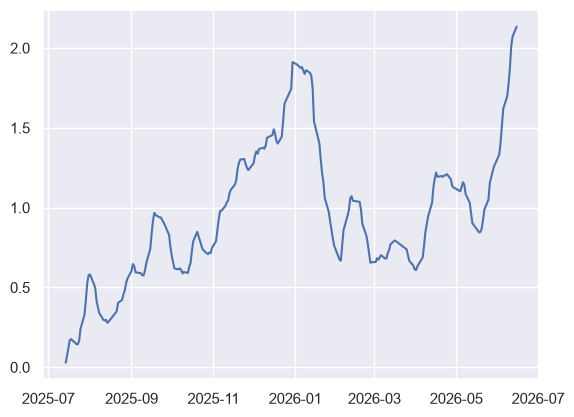

In [60]:
plt.plot((1+long_short['long_short_return']).cumprod()-1)

In [ ]:
news = pd.read_csv('news_df.csv')